## Now we are going to train our data for model 

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
spark = SparkSession.builder \
.appName("Amazon Product Bestseller Churn") \
.getOrCreate()

spark.sparkContext.setLogLevel("WARN")

In [2]:
"""Adding Different important Libraries require for the project"""
from pyspark.sql.functions import col, count, when
from pyspark.sql.functions import col, countDistinct
from pyspark.sql.functions import col, round, when
from pyspark.sql.functions import avg
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
path = r"balanced_df.csv"

Amazon_DF = spark.read.csv(
    path,
    header=True,
    inferSchema=True,
    multiLine=True,
    escape='"',
    quote='"'
)

print(f"Rows: {Amazon_DF.count()}, Columns: {len(Amazon_DF.columns)}")

print("Amazon Dataset")
Amazon_DF.printSchema()

Amazon_DF.show(10)


Rows: 25742, Columns: 13
Amazon Dataset
root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- stars: double (nullable = true)
 |-- reviews: integer (nullable = true)
 |-- price: double (nullable = true)
 |-- listPrice: double (nullable = true)
 |-- category_id: integer (nullable = true)
 |-- isBestSeller: integer (nullable = true)
 |-- boughtInLastMonth: integer (nullable = true)
 |-- category_name: string (nullable = true)
 |-- savings_pct: double (nullable = true)
 |-- is_high_discount: integer (nullable = true)
 |-- is_highly_rated: integer (nullable = true)

+----------+--------------------+-----+-------+-----+---------+-----------+------------+-----------------+--------------+-----------+----------------+---------------+
|      asin|               title|stars|reviews|price|listPrice|category_id|isBestSeller|boughtInLastMonth| category_name|savings_pct|is_high_discount|is_highly_rated|
+----------+--------------------+-----+-------+-----+---------+-----

## Spliting our dataset into 80/20% train and test dataset 
### And we include the seed = 42 for reproduceibility, Also we use the more corelated column for the models 

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.classification import LogisticRegression


In [5]:
# Split the data
trainingDF, testDF = Amazon_DF.select(
    "isBestSeller",
    "stars",
    "reviews",
    "listPrice",
    "boughtInLastMonth",
    "savings_pct",
    "is_high_discount",
    "is_highly_rated"
).randomSplit([0.80, 0.20], seed=42)

# Count rows in each split
train_count = trainingDF.count()
test_count = testDF.count()
total_count = Amazon_DF.count()

print(f"Training set rows: {train_count}")
print(f"Test set rows: {test_count}")
print(f"Total rows: {total_count}")
print(f"Train %: {train_count / total_count * 100:.2f}%")
print(f"Test %: {test_count / total_count * 100:.2f}%")


Training set rows: 20597
Test set rows: 5145
Total rows: 25742
Train %: 80.01%
Test %: 19.99%


### After that we have to make Features for training and label will be our target variable 

In [6]:
label_col = "isBestSeller"

feature_cols = [
    "stars",
    "reviews",
    "listPrice",
    "boughtInLastMonth",
    "savings_pct",
    "is_high_discount",
    "is_highly_rated"
]


In [7]:
vecAssembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="raw_features"
)


In [8]:
scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withMean=True,
    withStd=True
)


In [ ]:

def train_and_evaluate(df, feature_cols, label_col, classifier, test_split=0.2, seed=42):
    # 1️⃣ Split the data
    trainDF, testDF = df.select(label_col, *feature_cols).randomSplit([1-test_split, test_split], seed=seed)
    
    # 2️⃣ Create Pipeline
    assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
    scaler = StandardScaler(inputCol="raw_features", outputCol="features", withMean=True, withStd=True)
    
    pipeline = Pipeline(stages=[assembler, scaler, classifier])
    
    # 3️⃣ Train the pipeline
    pipelineModel = pipeline.fit(trainDF)
    
    # 4️⃣ Make predictions
    predictions = pipelineModel.transform(testDF)
    
    # 5️⃣ Evaluate with ROC-AUC
    evaluator = BinaryClassificationEvaluator(
        labelCol=label_col,
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )
    auc = evaluator.evaluate(predictions)
    print(f"ROC-AUC: {auc:.4f}")
    
    # 6️⃣ Optional: Show first 10 predictions safely
    cols_to_show = [label_col, "prediction"]
    if "probability" in predictions.columns:
        cols_to_show.insert(1, "probability")
    predictions.select(*cols_to_show).show(10, truncate=False)
    
    return predictions, pipelineModel, auc


In [ ]:


def visualize_binary_classification(pipelineModel, predictions, feature_cols, label_col="isBestSeller"):
    # ------------------------------
    # 0️⃣ Extract classifier from pipeline
    # ------------------------------
    model = pipelineModel.stages[-1] 
    
    # ------------------------------
    # 1️⃣ Overall Metrics (Works for ALL models)
    # ------------------------------
    # We use MulticlassClassificationEvaluator to get Accuracy, Precision, Recall, and F1
    # because it works for all models, unlike model.summary
    eval_acc = MulticlassClassificationEvaluator(labelCol=label_col, metricName="accuracy")
    eval_f1 = MulticlassClassificationEvaluator(labelCol=label_col, metricName="f1")
    eval_prec = MulticlassClassificationEvaluator(labelCol=label_col, metricName="weightedPrecision")
    eval_recall = MulticlassClassificationEvaluator(labelCol=label_col, metricName="weightedRecall")
    
    # ROC-AUC
    eval_auc = BinaryClassificationEvaluator(labelCol=label_col, rawPredictionCol="rawPrediction", metricName="areaUnderROC")

    metrics = {
        "Accuracy": eval_acc.evaluate(predictions),
        "AUC": eval_auc.evaluate(predictions),
        "F1-Score": eval_f1.evaluate(predictions),
        "Precision": eval_prec.evaluate(predictions),
        "Recall": eval_recall.evaluate(predictions)
    }

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="magma")
    plt.title("Model Performance Metrics", fontsize=14)
    plt.ylim(0, 1.1)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width()/2., p.get_height()), ha="center", va="bottom")
    plt.show()

    # ------------------------------
    # 2️⃣ Confusion Matrix (Works for ALL models)
    # ------------------------------
    pred_pd = predictions.select(label_col, "prediction").toPandas()
    confusion = pd.crosstab(pred_pd[label_col], pred_pd["prediction"], rownames=['Actual'], colnames=['Predicted'])
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", ax=ax[0])
    ax[0].set_title("Confusion Matrix (Counts)")
    
    confusion_norm = confusion.div(confusion.sum(axis=1), axis=0)
    sns.heatmap(confusion_norm, annot=True, fmt=".2f", cmap="Blues", ax=ax[1])
    ax[1].set_title("Confusion Matrix (Normalized)")
    plt.show()

    # ------------------------------
    # 3️⃣ ROC Curve (Manual calculation for non-LR models)
    # ------------------------------
    # If the model has a summary (Logistic Regression), use it. 
    # Otherwise, we don't plot it here to keep the function fast.
    summary = getattr(model, "summary", None)
    if summary is not None and hasattr(summary, "roc"):
        roc = summary.roc.toPandas()
        plt.figure(figsize=(6, 5))
        plt.plot(roc["FPR"], roc["TPR"], label=f"AUC: {metrics['AUC']:.2f}")
        plt.plot([0, 1], [0, 1], 'r--')
        plt.title("ROC Curve (Logistic Regression)")
        plt.legend()
        plt.show()

    # ------------------------------
    # 4️⃣ Feature Importance Visualization
    # ------------------------------
    # This handles both Coefficients (LR/SVM) and Feature Importance (Trees)
    feat_data = []
    if hasattr(model, "coefficients"):
        feat_data = model.coefficients.toArray()
    elif hasattr(model, "featureImportances"):
        feat_data = model.featureImportances.toArray()

    if len(feat_data) > 0:
        importance_df = pd.DataFrame({'Feature': feature_cols, 'Value': feat_data})
        importance_df = importance_df.sort_values(by="Value", ascending=False)

        plt.figure(figsize=(10, 6))
        sns.barplot(x="Value", y="Feature", data=importance_df, palette="viridis")
        plt.title("Feature Importance / Coefficients")
        plt.show()

ROC-AUC: 0.8324
+------------+----------------------------------------+----------+
|isBestSeller|probability                             |prediction|
+------------+----------------------------------------+----------+
|0           |[0.9798718106871421,0.02012818931285787]|0.0       |
|0           |[0.9798718106871421,0.02012818931285787]|0.0       |
|0           |[0.9798718106871421,0.02012818931285787]|0.0       |
|0           |[0.9798718106871421,0.02012818931285787]|0.0       |
|0           |[0.9798718106871421,0.02012818931285787]|0.0       |
|0           |[0.9798718106871421,0.02012818931285787]|0.0       |
|0           |[0.9798718106871421,0.02012818931285787]|0.0       |
|0           |[0.9798718106871421,0.02012818931285787]|0.0       |
|0           |[0.9798718106871421,0.02012818931285787]|0.0       |
|0           |[0.9798718106871421,0.02012818931285787]|0.0       |
+------------+----------------------------------------+----------+
only showing top 10 rows


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_19248\340962605.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="magma")


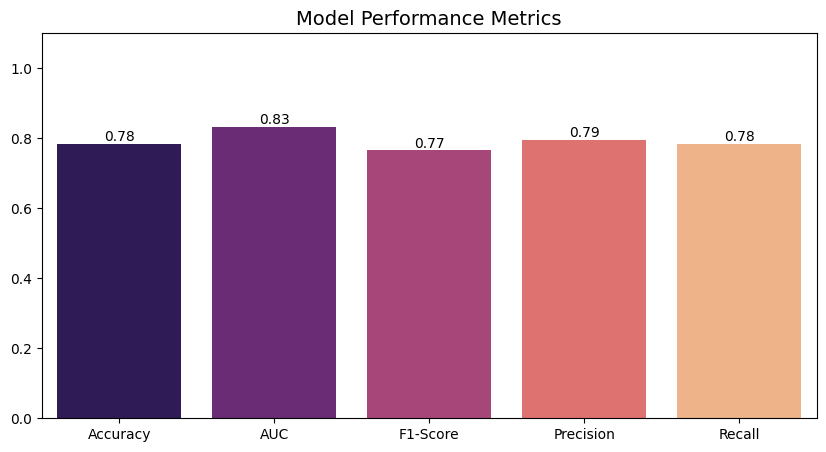

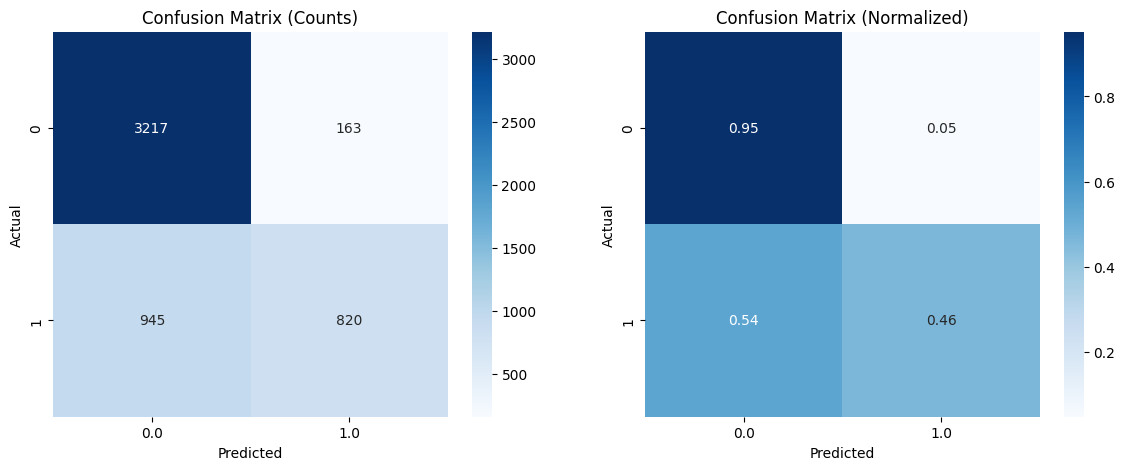

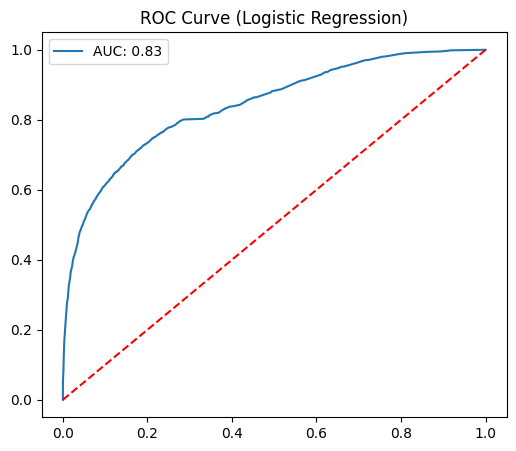

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_19248\340962605.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Value", y="Feature", data=importance_df, palette="viridis")


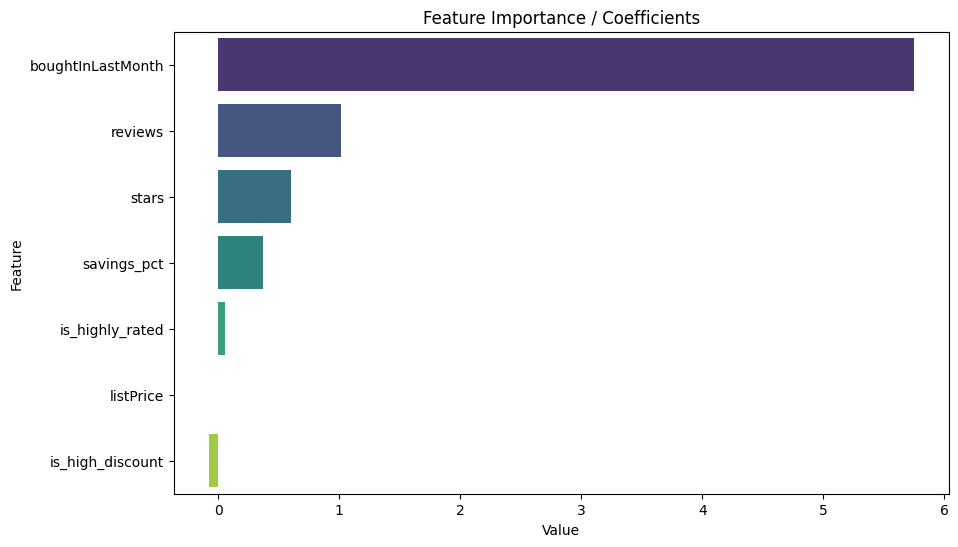

In [ ]:


# Define the model
lr = LogisticRegression(labelCol="isBestSeller", featuresCol="features")

# Step A: Train and Evaluate
# This handles the splitting, scaling, and fitting
predictions, lr_pipeline_model, auc_score = train_and_evaluate(
    df=Amazon_DF, 
    feature_cols=feature_cols, 
    label_col="isBestSeller", 
    classifier=lr
)

# Step B: Visualize
# We use the outputs from Step A here
visualize_binary_classification(
    pipelineModel=lr_pipeline_model, 
    predictions=predictions, 
    feature_cols=feature_cols, 
    label_col="isBestSeller"
)

ROC-AUC: 0.7838
+------------+---------------------------------------+----------+
|isBestSeller|probability                            |prediction|
+------------+---------------------------------------+----------+
|0           |[0.6860082027492541,0.3139917972507459]|0.0       |
|0           |[0.6860082027492541,0.3139917972507459]|0.0       |
|0           |[0.6860082027492541,0.3139917972507459]|0.0       |
|0           |[0.6860082027492541,0.3139917972507459]|0.0       |
|0           |[0.6860082027492541,0.3139917972507459]|0.0       |
|0           |[0.6860082027492541,0.3139917972507459]|0.0       |
|0           |[0.6860082027492541,0.3139917972507459]|0.0       |
|0           |[0.6860082027492541,0.3139917972507459]|0.0       |
|0           |[0.6860082027492541,0.3139917972507459]|0.0       |
|0           |[0.6860082027492541,0.3139917972507459]|0.0       |
+------------+---------------------------------------+----------+
only showing top 10 rows


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_19248\340962605.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="magma")


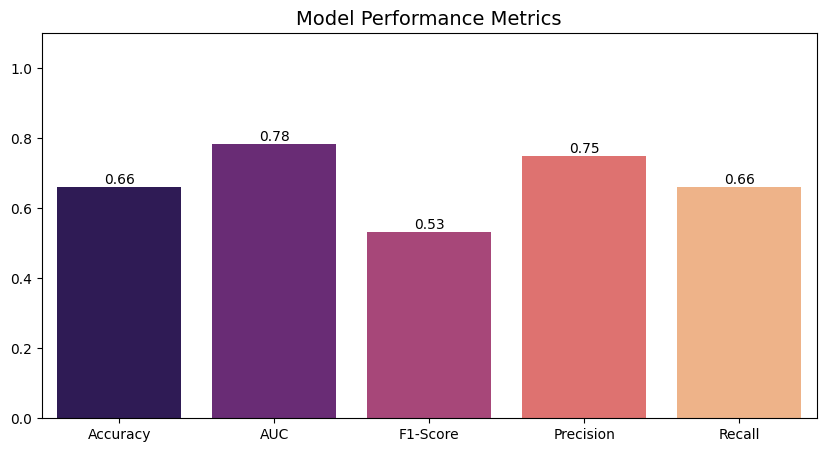

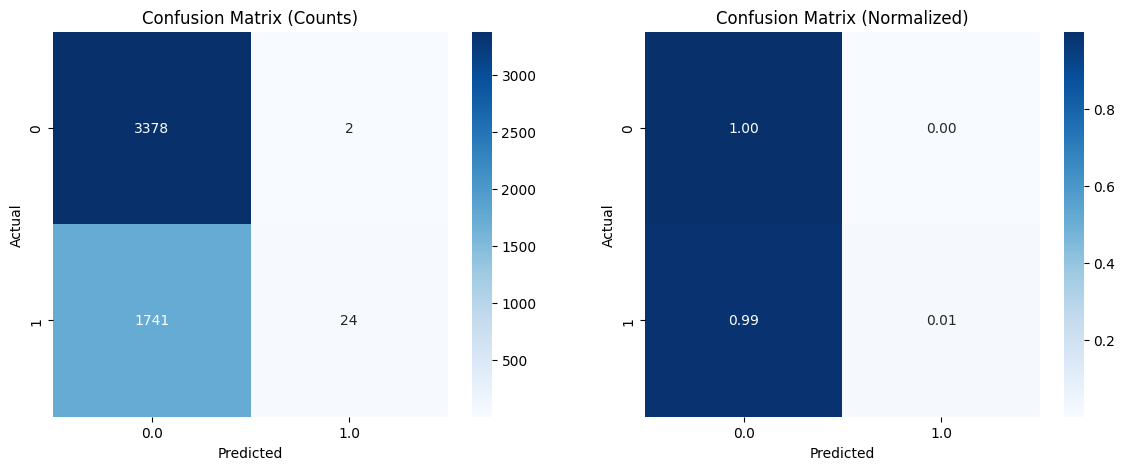

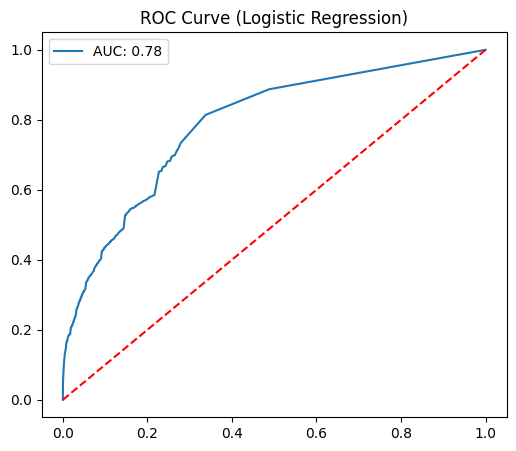

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_19248\340962605.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Value", y="Feature", data=importance_df, palette="viridis")


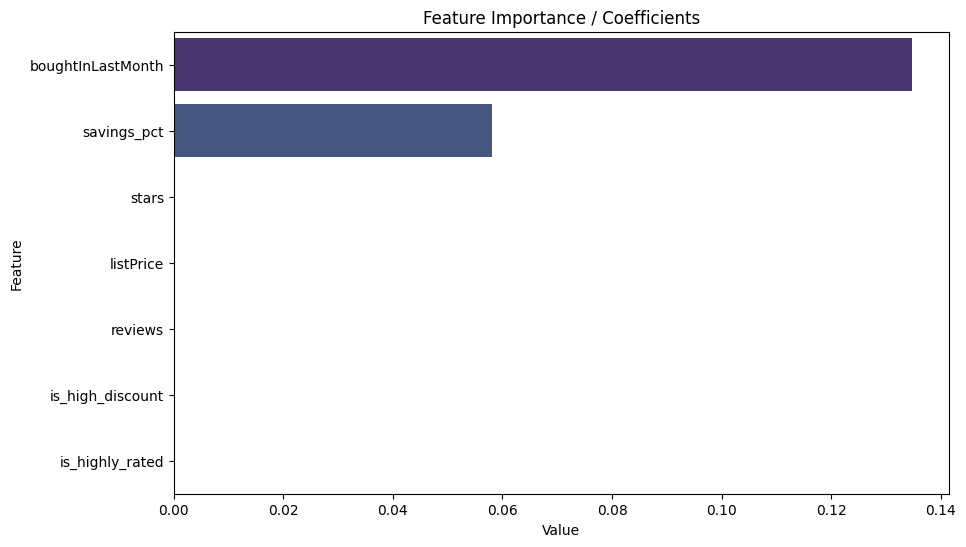

In [ ]:


# 1️⃣ Define the Lasso Model
# regParam: The strength of the penalty (start with 0.1)
# elasticNetParam: 1.0 makes it a pure Lasso model
lasso_lr = LogisticRegression(
    labelCol="isBestSeller", 
    featuresCol="features",
    regParam=0.1, 
    elasticNetParam=1.0
)

# 2️⃣ Step A: Train and Evaluate
predictions_lasso, lasso_pipeline_model, auc_lasso = train_and_evaluate(
    df=Amazon_DF, 
    feature_cols=feature_cols, 
    label_col="isBestSeller", 
    classifier=lasso_lr
)

# 3️⃣ Step B: Visualize
visualize_binary_classification(
    pipelineModel=lasso_pipeline_model, 
    predictions=predictions_lasso, 
    feature_cols=feature_cols, 
    label_col="isBestSeller"
)

ROC-AUC: 0.7656
+------------+----------------------------------------+----------+
|isBestSeller|probability                             |prediction|
+------------+----------------------------------------+----------+
|0           |[0.8976649364827136,0.10233506351728638]|0.0       |
|0           |[0.8976649364827136,0.10233506351728638]|0.0       |
|0           |[0.8976649364827136,0.10233506351728638]|0.0       |
|0           |[0.8976649364827136,0.10233506351728638]|0.0       |
|0           |[0.8976649364827136,0.10233506351728638]|0.0       |
|0           |[0.8976649364827136,0.10233506351728638]|0.0       |
|0           |[0.8976649364827136,0.10233506351728638]|0.0       |
|0           |[0.8976649364827136,0.10233506351728638]|0.0       |
|0           |[0.8976649364827136,0.10233506351728638]|0.0       |
|0           |[0.8976649364827136,0.10233506351728638]|0.0       |
+------------+----------------------------------------+----------+
only showing top 10 rows


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_19248\340962605.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="magma")


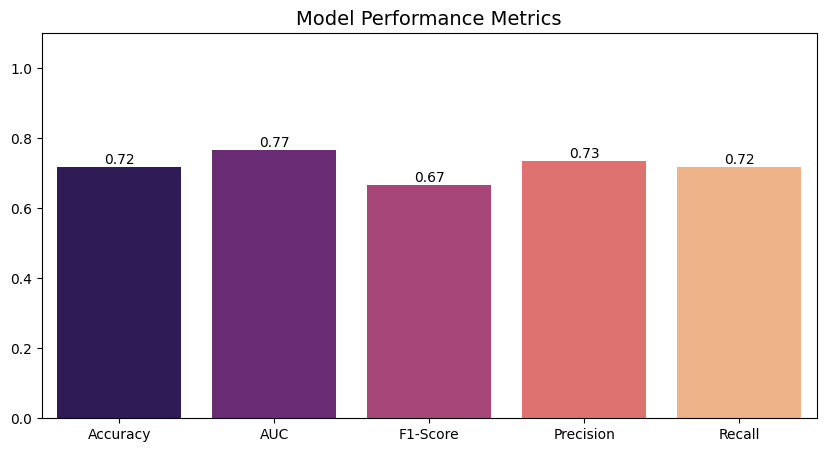

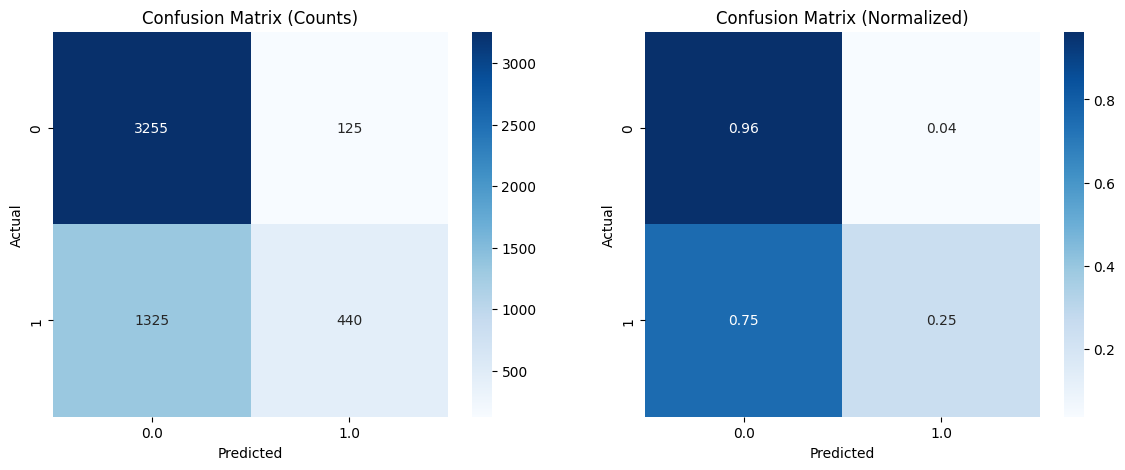

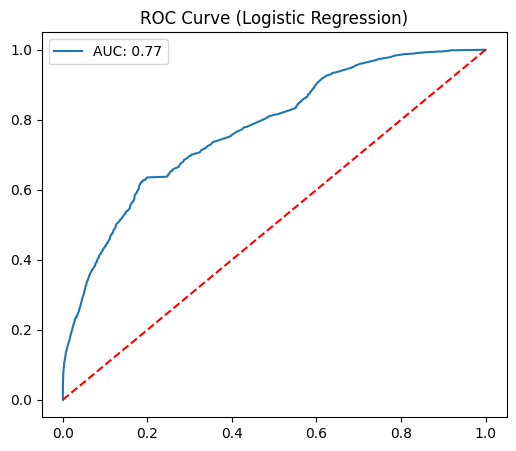

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_19248\340962605.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Value", y="Feature", data=importance_df, palette="viridis")


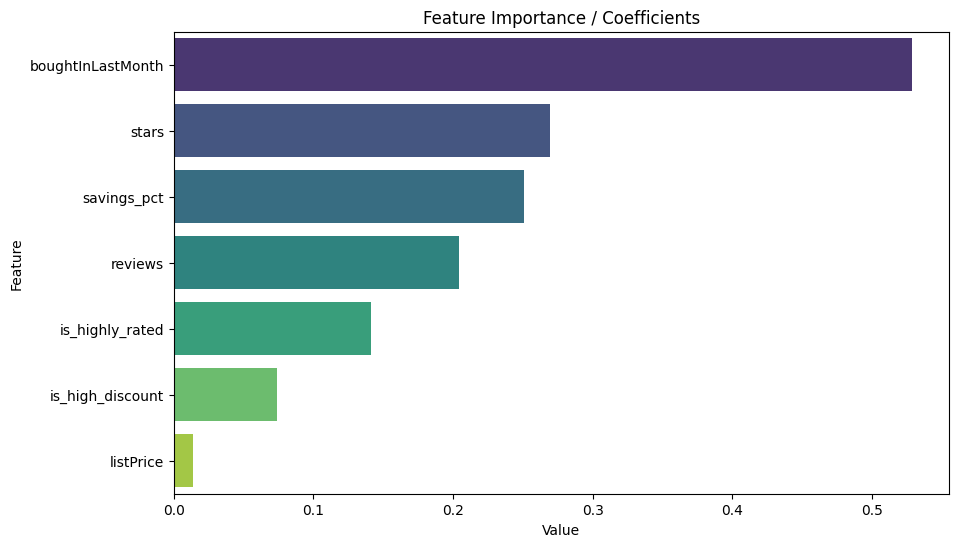

In [ ]:
from pyspark.ml.classification import LogisticRegression

# 1️⃣ Define the Ridge Model
# regParam: The strength of the penalty
# elasticNetParam: 0.0 makes it a pure Ridge (L2) model
ridge_lr = LogisticRegression(
    labelCol="isBestSeller", 
    featuresCol="features",
    regParam=0.1, 
    elasticNetParam=0.0
)

# 2️⃣ Step A: Train and Evaluate
predictions_ridge, ridge_pipeline_model, auc_ridge = train_and_evaluate(
    df=Amazon_DF, 
    feature_cols=feature_cols, 
    label_col="isBestSeller", 
    classifier=ridge_lr
)

# 3️⃣ Step B: Visualize
visualize_binary_classification(
    pipelineModel=ridge_pipeline_model, 
    predictions=predictions_ridge, 
    feature_cols=feature_cols, 
    label_col="isBestSeller"
)

ROC-AUC: 0.5512
+------------+----------------------------------------+----------+
|isBestSeller|probability                             |prediction|
+------------+----------------------------------------+----------+
|0           |[0.9804957334416904,0.01950426655830963]|0.0       |
|0           |[0.9804957334416904,0.01950426655830963]|0.0       |
|0           |[0.9804957334416904,0.01950426655830963]|0.0       |
|0           |[0.9804957334416904,0.01950426655830963]|0.0       |
|0           |[0.9804957334416904,0.01950426655830963]|0.0       |
|0           |[0.9804957334416904,0.01950426655830963]|0.0       |
|0           |[0.9804957334416904,0.01950426655830963]|0.0       |
|0           |[0.9804957334416904,0.01950426655830963]|0.0       |
|0           |[0.9804957334416904,0.01950426655830963]|0.0       |
|0           |[0.9804957334416904,0.01950426655830963]|0.0       |
+------------+----------------------------------------+----------+
only showing top 10 rows


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_19248\340962605.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="magma")


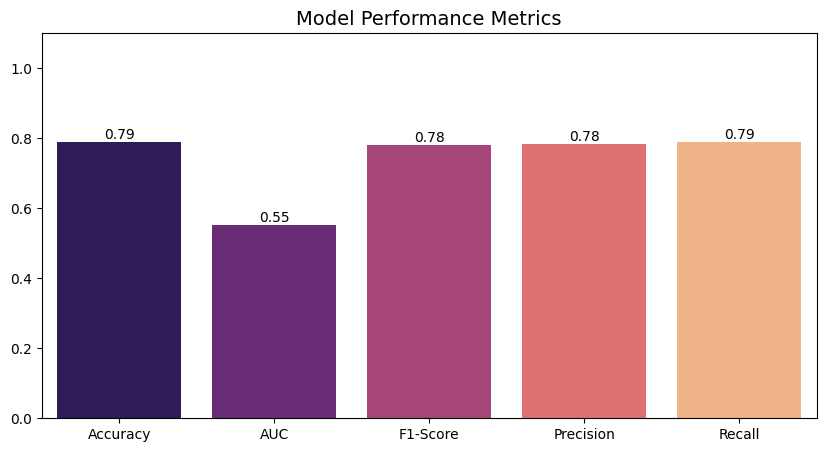

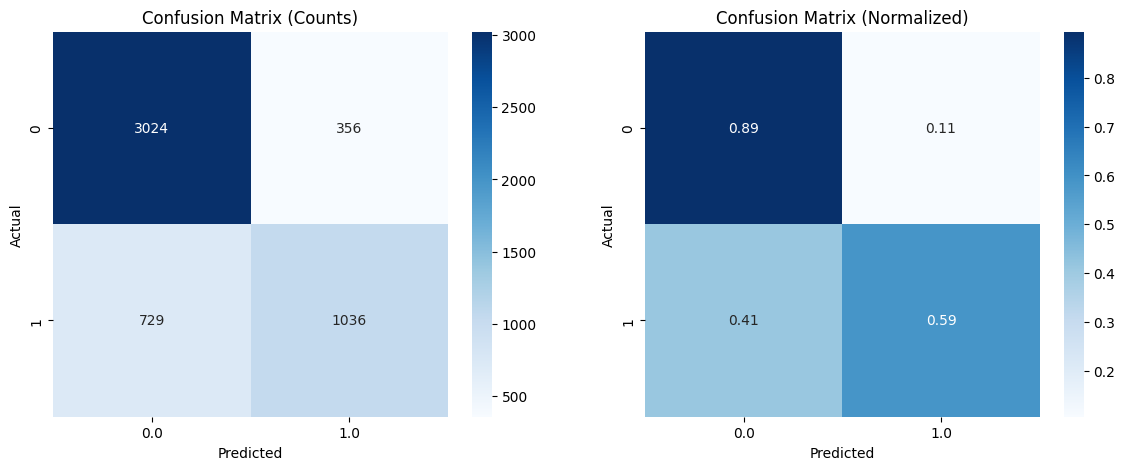

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_19248\340962605.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Value", y="Feature", data=importance_df, palette="viridis")


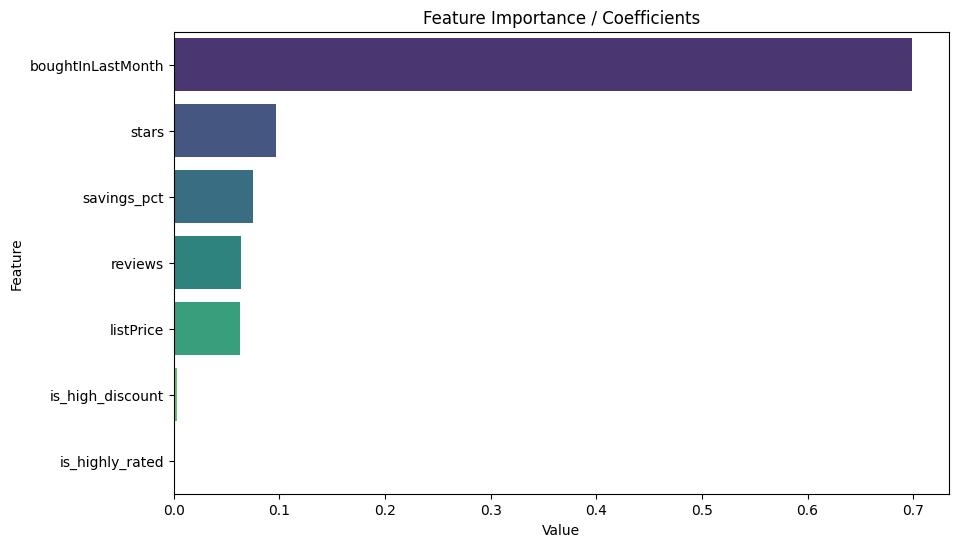

In [33]:
from pyspark.ml.classification import DecisionTreeClassifier

# 1️⃣ Define the Decision Tree Classifier
# maxDepth: How many "levels" the tree can have. 
# 5 is a good starting point to prevent overfitting.
dt_classifier = DecisionTreeClassifier(
    labelCol="isBestSeller", 
    featuresCol="features", 
    maxDepth=15
)

# 2️⃣ Step A: Train and Evaluate
predictions_dt, dt_pipeline_model, auc_dt = train_and_evaluate(
    df=Amazon_DF, 
    feature_cols=feature_cols, 
    label_col="isBestSeller", 
    classifier=dt_classifier
)

# 3️⃣ Step B: Visualize
visualize_binary_classification(
    pipelineModel=dt_pipeline_model, 
    predictions=predictions_dt, 
    feature_cols=feature_cols, 
    label_col="isBestSeller"
)

ROC-AUC: 0.8611
+------------+-----------------------------------------+----------+
|isBestSeller|probability                              |prediction|
+------------+-----------------------------------------+----------+
|0           |[0.9696511065016337,0.030348893498366333]|0.0       |
|0           |[0.9696511065016337,0.030348893498366333]|0.0       |
|0           |[0.9696511065016337,0.030348893498366333]|0.0       |
|0           |[0.9696511065016337,0.030348893498366333]|0.0       |
|0           |[0.9696511065016337,0.030348893498366333]|0.0       |
|0           |[0.9696511065016337,0.030348893498366333]|0.0       |
|0           |[0.9696511065016337,0.030348893498366333]|0.0       |
|0           |[0.9696511065016337,0.030348893498366333]|0.0       |
|0           |[0.9696511065016337,0.030348893498366333]|0.0       |
|0           |[0.9696511065016337,0.030348893498366333]|0.0       |
+------------+-----------------------------------------+----------+
only showing top 10 rows


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_19248\340962605.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="magma")


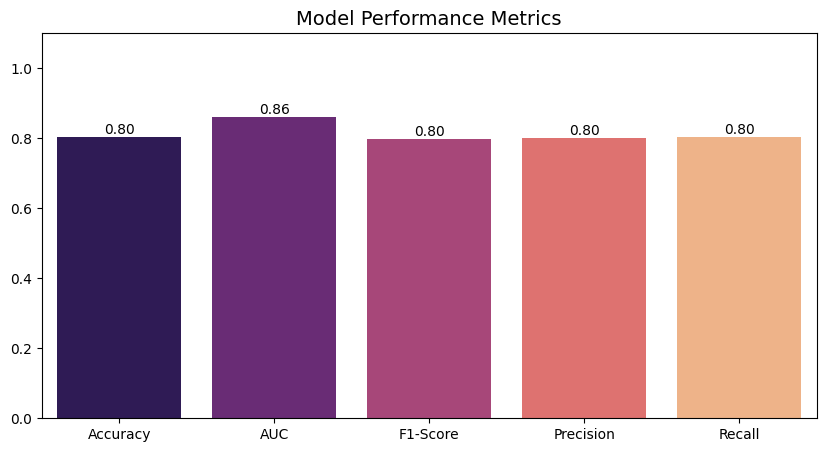

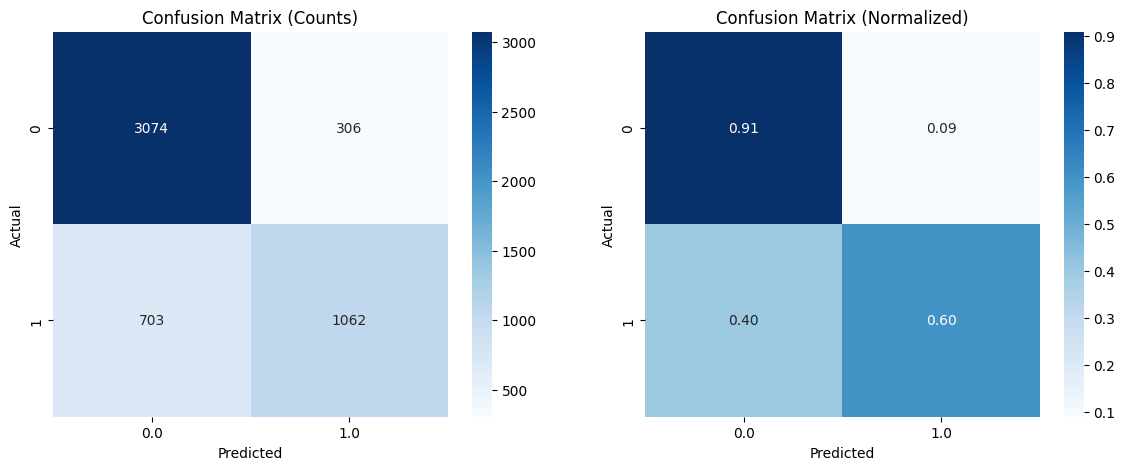

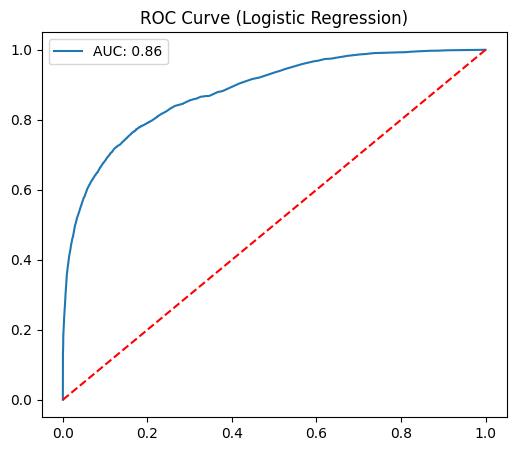

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_19248\340962605.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Value", y="Feature", data=importance_df, palette="viridis")


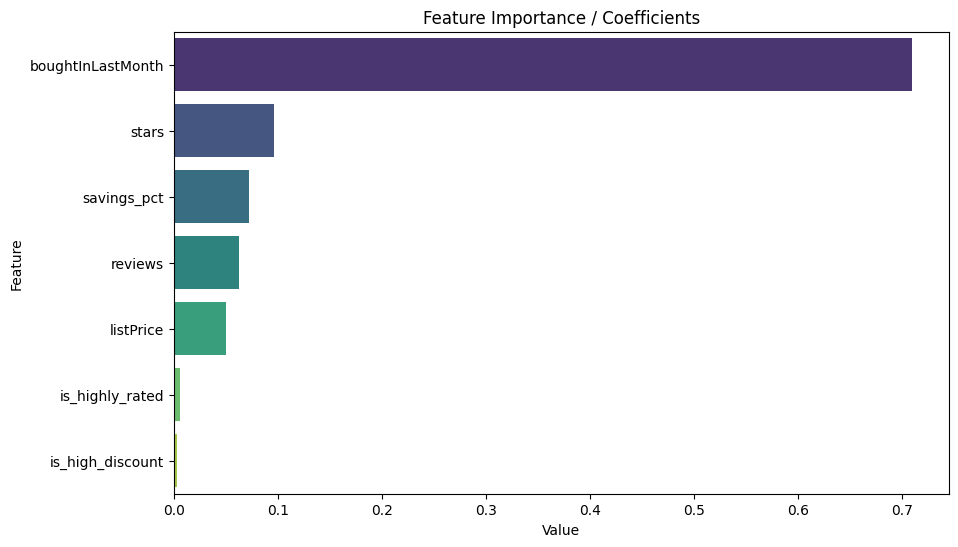

In [37]:
from pyspark.ml.classification import RandomForestClassifier

# 1️⃣ Define the Random Forest Classifier
# numTrees: Number of trees in the forest (100 is a standard starting point)
# maxDepth: Depth of each individual tree
rf_classifier = RandomForestClassifier(
    labelCol="isBestSeller", 
    featuresCol="features", 
    numTrees=200, 
    maxDepth=10, 
    seed=42
)

# 2️⃣ Step A: Train and Evaluate
predictions_rf, rf_pipeline_model, auc_rf = train_and_evaluate(
    df=Amazon_DF, 
    feature_cols=feature_cols, 
    label_col="isBestSeller", 
    classifier=rf_classifier
)

# 3️⃣ Step B: Visualize
visualize_binary_classification(
    pipelineModel=rf_pipeline_model, 
    predictions=predictions_rf, 
    feature_cols=feature_cols, 
    label_col="isBestSeller"
)

ROC-AUC: 0.8626
+------------+-----------------------------------------+----------+
|isBestSeller|probability                              |prediction|
+------------+-----------------------------------------+----------+
|0           |[0.9711219388348519,0.028878061165148128]|0.0       |
|0           |[0.9711219388348519,0.028878061165148128]|0.0       |
|0           |[0.9711219388348519,0.028878061165148128]|0.0       |
|0           |[0.9711219388348519,0.028878061165148128]|0.0       |
|0           |[0.9711219388348519,0.028878061165148128]|0.0       |
|0           |[0.9711219388348519,0.028878061165148128]|0.0       |
|0           |[0.9711219388348519,0.028878061165148128]|0.0       |
|0           |[0.9711219388348519,0.028878061165148128]|0.0       |
|0           |[0.9711219388348519,0.028878061165148128]|0.0       |
|0           |[0.9711219388348519,0.028878061165148128]|0.0       |
+------------+-----------------------------------------+----------+
only showing top 10 rows


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_19248\340962605.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="magma")


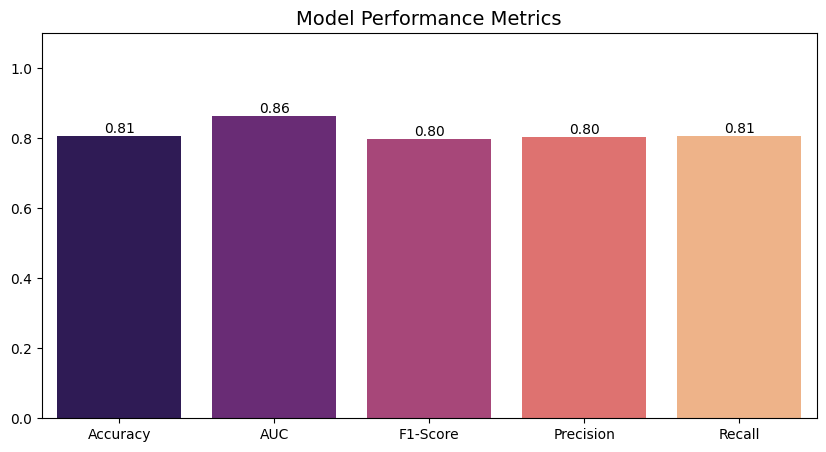

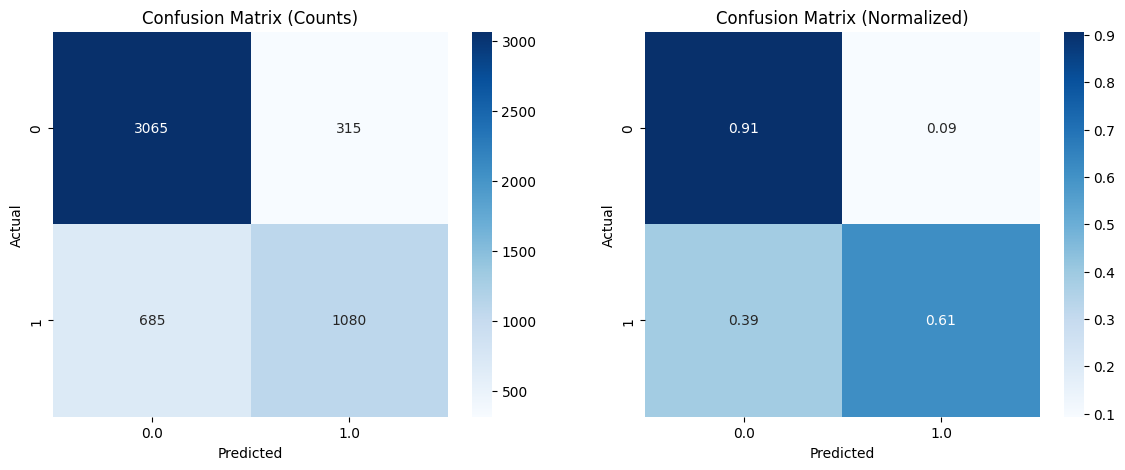

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_19248\340962605.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Value", y="Feature", data=importance_df, palette="viridis")


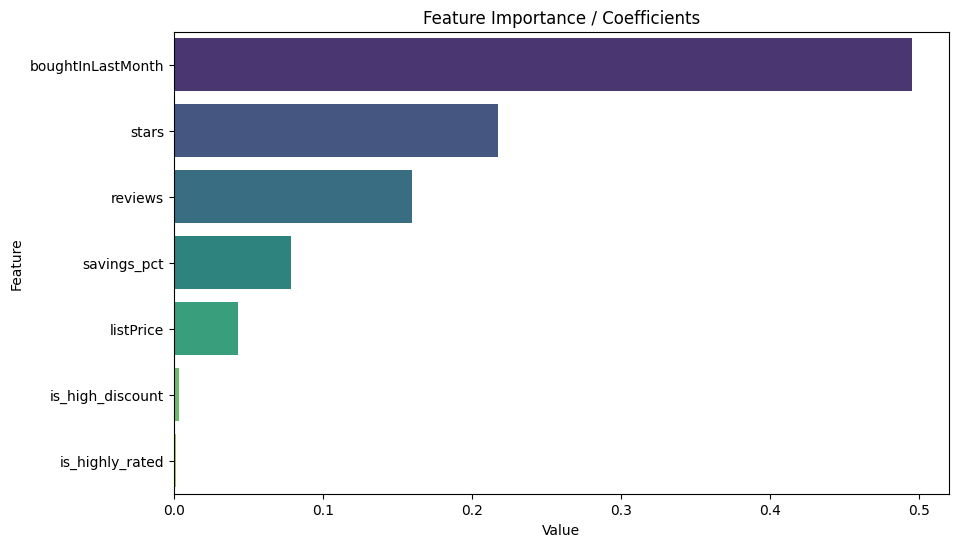

In [39]:
from pyspark.ml.classification import GBTClassifier

# 1️⃣ Define the Gradient Boosted Trees Classifier
# maxIter: The number of trees (iterations). 10-20 is good for testing; 100+ for production.
# maxDepth: Usually kept small (3-5) because GBT builds on errors.
gbt_classifier = GBTClassifier(
    labelCol="isBestSeller", 
    featuresCol="features", 
    maxIter=50, 
    maxDepth=5,
    seed=42
)

# 2️⃣ Step A: Train and Evaluate
predictions_gbt, gbt_pipeline_model, auc_gbt = train_and_evaluate(
    df=Amazon_DF, 
    feature_cols=feature_cols, 
    label_col="isBestSeller", 
    classifier=gbt_classifier
)

# 3️⃣ Step B: Visualize
visualize_binary_classification(
    pipelineModel=gbt_pipeline_model, 
    predictions=predictions_gbt, 
    feature_cols=feature_cols, 
    label_col="isBestSeller"
)

ROC-AUC: 0.8552
+------------+-----------------------------------------+----------+
|isBestSeller|probability                              |prediction|
+------------+-----------------------------------------+----------+
|0           |[0.9898353910401066,0.010164608959893339]|0.0       |
|0           |[0.9898353910401066,0.010164608959893339]|0.0       |
|0           |[0.9898353910401066,0.010164608959893339]|0.0       |
|0           |[0.9898353910401066,0.010164608959893339]|0.0       |
|0           |[0.9898353910401066,0.010164608959893339]|0.0       |
|0           |[0.9898353910401066,0.010164608959893339]|0.0       |
|0           |[0.9898353910401066,0.010164608959893339]|0.0       |
|0           |[0.9898353910401066,0.010164608959893339]|0.0       |
|0           |[0.9898353910401066,0.010164608959893339]|0.0       |
|0           |[0.9898353910401066,0.010164608959893339]|0.0       |
+------------+-----------------------------------------+----------+
only showing top 10 rows


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_19248\340962605.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="magma")


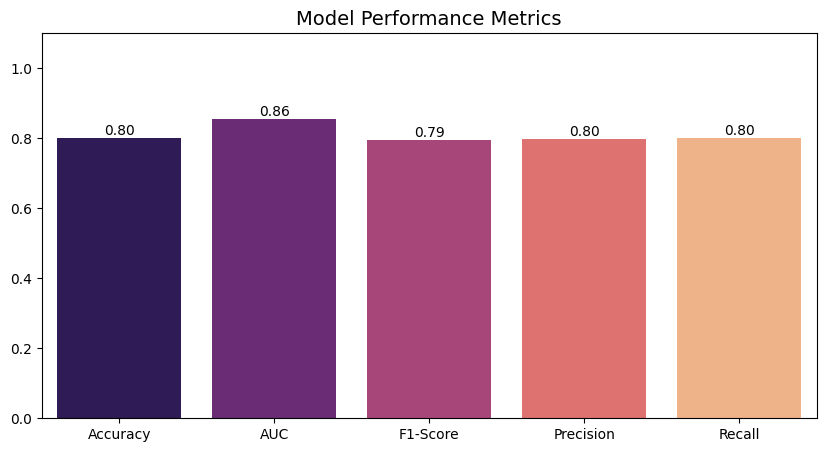

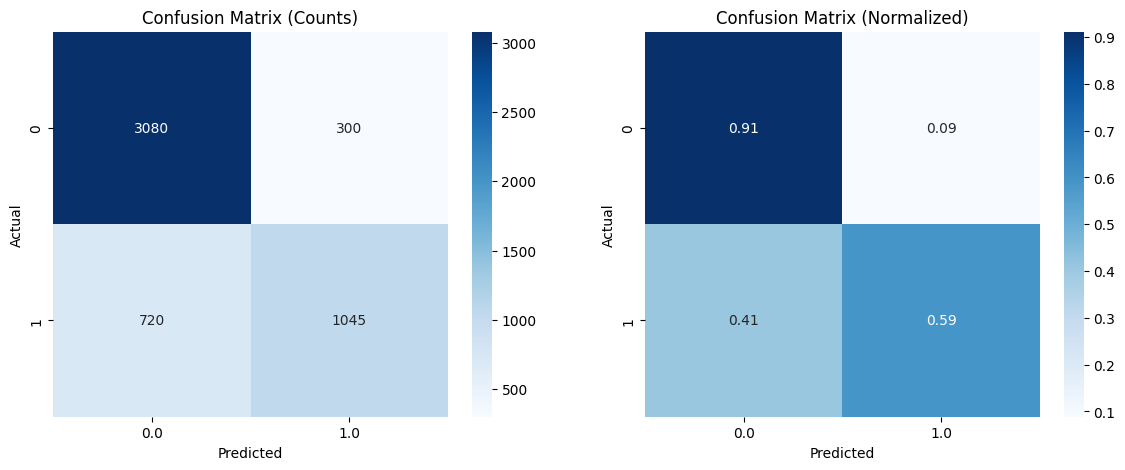

In [46]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

layers = [7, 32, 16, 2]

nn_classifier = MultilayerPerceptronClassifier(
    labelCol="isBestSeller",
    featuresCol="features",
    layers=layers,
    blockSize=256,
    seed=42,
    maxIter=200
)

# 2️⃣ Step A: Train and Evaluate
predictions_nn, nn_pipeline_model, auc_nn = train_and_evaluate(
    df=Amazon_DF, 
    feature_cols=feature_cols, 
    label_col="isBestSeller", 
    classifier=nn_classifier
)

# 3️⃣ Step B: Visualize
visualize_binary_classification(
    pipelineModel=nn_pipeline_model, 
    predictions=predictions_nn, 
    feature_cols=feature_cols, 
    label_col="isBestSeller"
)

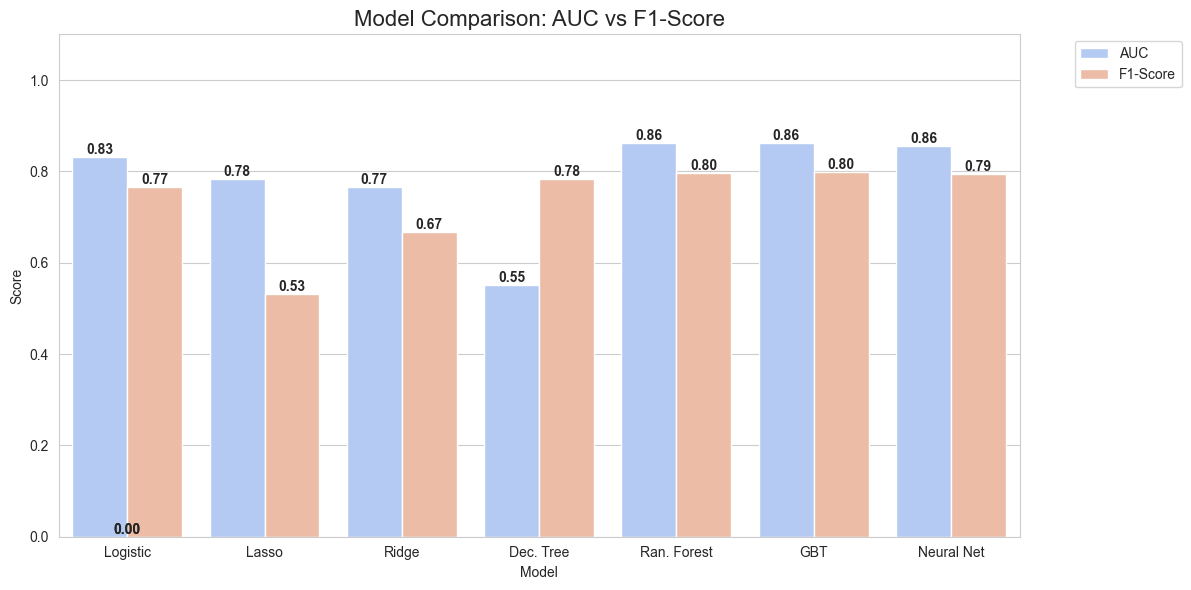

--- Model Ranking (by AUC) ---
         Model       AUC  F1-Score
5          GBT  0.862572  0.799301
4  Ran. Forest  0.861088  0.796901
6   Neural Net  0.855196  0.794161
0     Logistic  0.832403  0.765168
1        Lasso  0.783754  0.531414
2        Ridge  0.765624  0.666843
3    Dec. Tree  0.551236  0.782171


In [48]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup the evaluators
# AUC needs the 'rawPrediction' column
eval_auc = BinaryClassificationEvaluator(labelCol="isBestSeller", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
# F1 needs the 'prediction' column
eval_f1 = MulticlassClassificationEvaluator(labelCol="isBestSeller", metricName="f1")

# 2. List of all your result DataFrames
model_results = [
    ("Logistic", predictions),
    ("Lasso", predictions_lasso),
    ("Ridge", predictions_ridge),
    ("Dec. Tree", predictions_dt),
    ("Ran. Forest", predictions_rf),
    ("GBT", predictions_gbt),
    ("Neural Net", predictions_nn)
]

# 3. Collect the metrics
data_for_plot = []

for name, preds in model_results:
    try:
        auc = eval_auc.evaluate(preds)
        f1 = eval_f1.evaluate(preds)
        data_for_plot.append({"Model": name, "AUC": auc, "F1-Score": f1})
    except Exception as e:
        print(f"Could not evaluate {name}: {e}")

# 4. Convert to Pandas and reshape
summary_df = pd.DataFrame(data_for_plot)
plot_df = summary_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

# 5. Create the Visualization
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric", palette="coolwarm")

plt.title("Model Comparison: AUC vs F1-Score", fontsize=16)
plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add labels on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Display the sorted ranking
print("--- Model Ranking (by AUC) ---")
print(summary_df.sort_values(by="AUC", ascending=False))